# Hồi quy tuyến tính bội

Lấy dữ liệu đã làm sạch:

In [292]:
system("git clone https://github.com/mhaih/btl_xstk.git")
setwd("btl_xstk")
gpu_clean <- read.csv("cleaned_data/gpu_ready_for_models.csv")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Cài đặt thư viện

In [ ]:
install.packages("GGally")
install.packages("car")
install.packages("lmtest")

Mục tiêu của phần này là xây dựng một mô hình dự đoán Max_Power dựa trên dữ liệu đã làm sạch từ phần trước.

Bắt đầu bằng việc chọn lọc các biến để xây dựng mô hình, sau đó từng bước đánh giá, kiểm định các giả định về mô hình.

## 1. Xây dựng mô hình

Trước hết, mô hình sẽ bỏ qua các biến phân loại như `Manufacturer`, `Memory_Type` và `Notebook_GPU`.

In [346]:
cols_to_ignore = c("Manufacturer", "Memory_Type", "Notebook_GPU")
gpu_filter <- gpu_clean[, !(names(gpu_clean) %in% cols_to_ignore)]

Như vậy, từ bộ dữ liệu đã làm sạch, ta sẽ sử dụng các dữ liệu sau:

In [295]:
names(gpu_filter)

[1] "Core_Speed"       "Max_Power"        "Memory"           "Memory_Bandwidth"
[5] "Memory_Speed"     "Memory_Bus"       "Process"          "ROPs"            
[9] "TMUs"

Trước tiên, ta cần đánh giá sơ bộ về dữ liệu dùng để dự báo, cụ thể cần để ý về mối quan hệ giữa biến mục tiêu với các biến dự báo, và giữa các biến dự báo với nhau. Ma trận sau đây có thể cho ta một cái nhìn tổng quát:

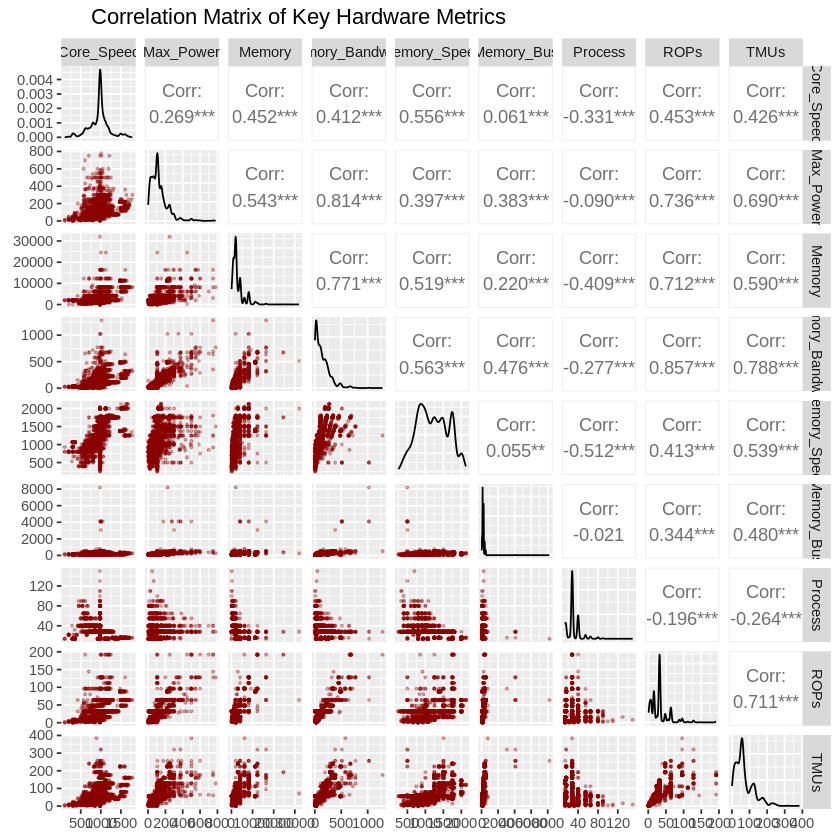

In [341]:
library(GGally)
p_pairs <- ggpairs(gpu_filter,
                   title = "     Correlation Matrix of Key Hardware Metrics",
                   lower = list(continuous = wrap("points", alpha = 0.3, size = 0.5, color = "darkred")))
p_pairs

Có thể thấy rằng:

Thứ nhất, quan hệ giữa Max_Power và các biến dự báo không tuyến tính một cách rõ ràng, thay vào đó các điểm dữ liệu có xu hướng toả rộng ra. Điều này gợi ý rằng một số giả định ban đầu về mô hình có thể bị vi phạm, ví dụ như tính tuyến tính, hoặc phân phối chuẩn của sai số.

Thứ hai, độ tương quan giữa Max_Power và các biến đều tương đối tốt, tuy nhiên độ tương quan giữa các biến với nhau cũng vậy, ví dụ như biến dự báo Memory_Bandwidth có tương quan khá cao với nhiều biến dự báo còn lại. Gợi ý rằng mô hình có thể gặp hiện tượng đa cộng tuyến.

Các phần sau sẽ phân tích sâu hơn và xử lý các yếu tố này. Bây giờ ta sẽ khởi tạo và bắt đầu xây dựng mô hình `base_model`:

$Max\_Power$

$=\beta_0+\beta_1*Core\_Speed+\beta_2*Max\_Power$

$+\beta_3*Memory+\beta_4*Memory\_Bandwidth+\beta_5*Memory\_Speed$

$+\beta_6*Memory\_Bus+\beta_7*Process+\beta_8*ROPs+\beta_9*TMUs$

In [296]:
base_model <- lm(Max_Power ~ ., data = gpu_filter)
base_model$coefficients

(Intercept)       Core_Speed           Memory Memory_Bandwidth 
    39.595009028     -0.027187152     -0.006362147      0.571461713 
    Memory_Speed       Memory_Bus          Process             ROPs 
    -0.004393924     -0.030304650      0.731992426      0.521820319 
            TMUs 
     0.306682321

Trước tiên, ta sẽ đánh giá hiện tượng đa cộng tuyến giữa các biến dự báo. Thước đo ta sẽ sử dụng là VIF, nếu VIF của một biến > 5,

In [297]:
library(car)
vif(base_model)

Core_Speed           Memory Memory_Bandwidth     Memory_Speed 
        1.686582         3.048072         8.022746         2.591191 
      Memory_Bus          Process             ROPs             TMUs 
        1.681180         1.487153         4.683502         3.100772

Kết quả của lệnh trên cho thấy biến Memory_Bandwidth có VIF > 5, ta sẽ thử loại biến khỏi mô hình và đánh giá mô hình mới (`model_1`):

In [298]:
model_1 <- lm(Max_Power ~ . - Memory_Bandwidth, data = gpu_filter)
vif(model_1)

Core_Speed       Memory Memory_Speed   Memory_Bus      Process         ROPs 
    1.606259     2.504398     2.188764     1.415735     1.470007     2.970254 
        TMUs 
    2.914136

Các biến dự báo của mô hình lúc này đã đều có VIF < 5. Ta tiến hành so sánh 2 mô hình `model_1` (mới) và `base_model` (cũ) sử dụng F-test với mức ý nghĩa 5%:
- $H_0: \beta_4 = 0$
- $H_1: \beta_4 ≠ 0$

In [299]:
anova(model_1, base_model)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3171,10742045,NA,NA,NA,NA
2,3170,8383906,1,2358139,891.6252,7.410028e-173


Có thể thấy rằng, mặc dù Memory_Bandwidth có độ tương quan khá cao với các biến khác, so sánh giữa mô hình có biến này (base_model) với mô hình không có (model_1) cho kết quả p-value thấp. Do đó ta chấp nhận base_model và tiếp tục tới bước kiểm định hệ số hồi quy với mức ý nghĩa 5%, sử dụng t-test:
- $H_0: \beta_i = 0$
- $H_1: \beta_i ≠ 0$

Kết quả của t-test cho từng biến có thể thu được từ lệnh sau:

In [348]:
summary(base_model)$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),39.595009028,6.0866549816,6.505217,8.982643e-11
Core_Speed,-0.027187152,0.0048898744,-5.559888,2.923334e-08
Memory,-0.006362147,0.0005972319,-10.652724,4.646996e-26
Memory_Bandwidth,0.571461713,0.0191379741,29.860094,7.410028e-173
Memory_Speed,-0.004393924,0.0034948702,-1.257250,2.087559e-01
Memory_Bus,-0.030304650,0.0045456873,-6.666682,3.074309e-11
Process,0.731992426,0.0878880665,8.328690,1.201034e-16
ROPs,0.521820319,0.0765411860,6.817510,1.104499e-11
TMUs,0.306682321,0.0315357708,9.724903,4.785030e-22


Dựa vào kết quả của lệnh trên, ta nhận ra ngay có p-value của Memory_Speed cao hơn mức ý nghĩa. Thử tiến hành loại biến này ra khỏi mô hình để có được mô hình mới model_2 và kiểm định hệ số hồi quy một lần nữa trên mô hình mới này:

In [349]:
model_2 <- lm(Max_Power ~ . - Memory_Speed, data = gpu_filter)
summary(model_2)$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),35.873547690,5.3189226036,6.744514,1.817456e-11
Core_Speed,-0.029530446,0.0045211469,-6.531627,7.549964e-11
Memory,-0.006326678,0.0005966198,-10.604203,7.676853e-26
Memory_Bandwidth,0.561979463,0.0175907951,31.947360,2.067780e-194
Memory_Bus,-0.028437419,0.0042966171,-6.618560,4.242465e-11
Process,0.770213495,0.0824703867,9.339273,1.771840e-20
ROPs,0.551919180,0.0727075364,7.590949,4.150026e-14
TMUs,0.297704189,0.0307194151,9.691076,6.602861e-22


So sánh base_model và model_2 bằng F-test với mức ý nghĩa 5%:
- $H_0: \beta_5 = 0$
- $H_1: \beta_5 ≠ 0$


In [302]:
anova(model_2, base_model)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3171,8388086,NA,NA,NA,NA
2,3170,8383906,1,4180.519,1.580677,0.2087559


Ta thu được p-value cao hơn mức ý nghĩa từ kiểm định trên, do đó ta chưa bác bỏ $H_0$, nghĩa là ta có thể nhận model_2 làm mô hình chính.

In [303]:
main_model <- model_2

## 2. Chẩn đoán mô hình
#### 2.1. Kiểm tra các giả định
- Tính tuyến tính của mô hình.
- Sai số ngẫu nhiên có phân phối chuẩn
- Sai số ngẫu nhiên có kỳ vọng bằng 0
- Sai số ngẫu nhiên có phương sai hằng

Trước tiên, ta có thể đánh giá sơ bộ về tính tuyến tính và phương sai hằng qua biểu đồ Residual vs Fitted

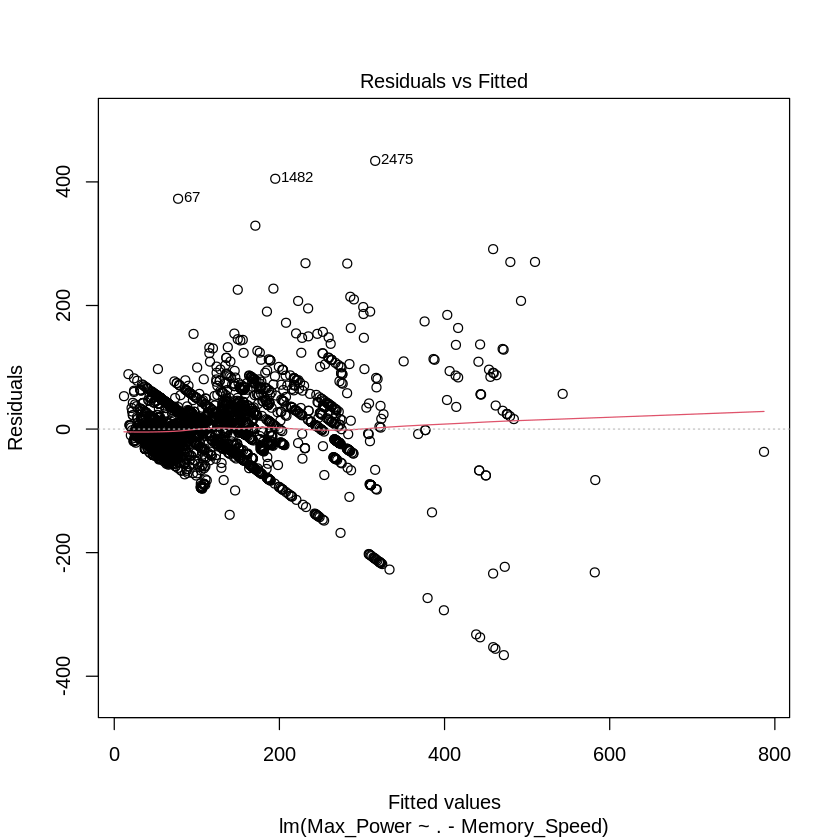

In [304]:
plot(main_model, which = 1)

Tính tuyến tính của mô hình có thể được chấp nhận khi trung bình của phần dư tại mỗi giá trị dự đoán - được thể hiện bởi đường màu đỏ - xấp xỉ 0. Ở biểu đồ này, đường màu đỏ cho ta thấy trung bình của các phần dư tương đối ổn định xung quanh đường y = 0 và có xu hướng hơi lệch ra xa y = 0 khi giá trị dự báo tăng lên, các điểm dữ liệu cũng thưa dần. Điều này gợi ý rằng sự chênh lệch này là không quá đáng kể và chủ yếu là do thiếu dữ liệu ở các giá trị dự báo lớn, do đó ta xem như giả định tuyến tính được thoả.

Giả định về phương sai hằng của sai số cũng có thể được đánh giá qua biểu đồ này. Có thể nhận thấy rằng khi các giá trị dự báo tăng lên, phân bố của các giá trị phần dư có xu hướng loe rộng ra (hình cái phễu). Điều này làm cho mô hình bị vi phạm giả định về phương sai hằng. Ta có thể kiểm tra kỹ hơn giả định về phương sai hằng bằng kiểm định Breusch-Pagan:

- $H_0$: các sai số có phương sai hằng.
- $H_1$: các sai số có phương sai thay đổi.

In [310]:
library(lmtest)
bptest(main_model)


	studentized Breusch-Pagan test

data:  main_model
BP = 741.07, df = 7, p-value < 2.2e-16


Với mức ý nghĩa 5%, ta có thể bác bỏ $H_0$, phù hợp với nhận định trước đó khi đánh giá biểu đồ Residual vs Fitted.

Tiếp theo, để kiểm tra giả định về phân phối chuẩn của sai số với giá trị kỳ vọng bằng 0, ta có thể đánh giá biểu đồ quantile-quantile (Q-Q plot), nếu các điểm dữ liệu nằm sát đường nét đứt, giả định về phân phối chuẩn của sai số có thể xem như thoả mãn:

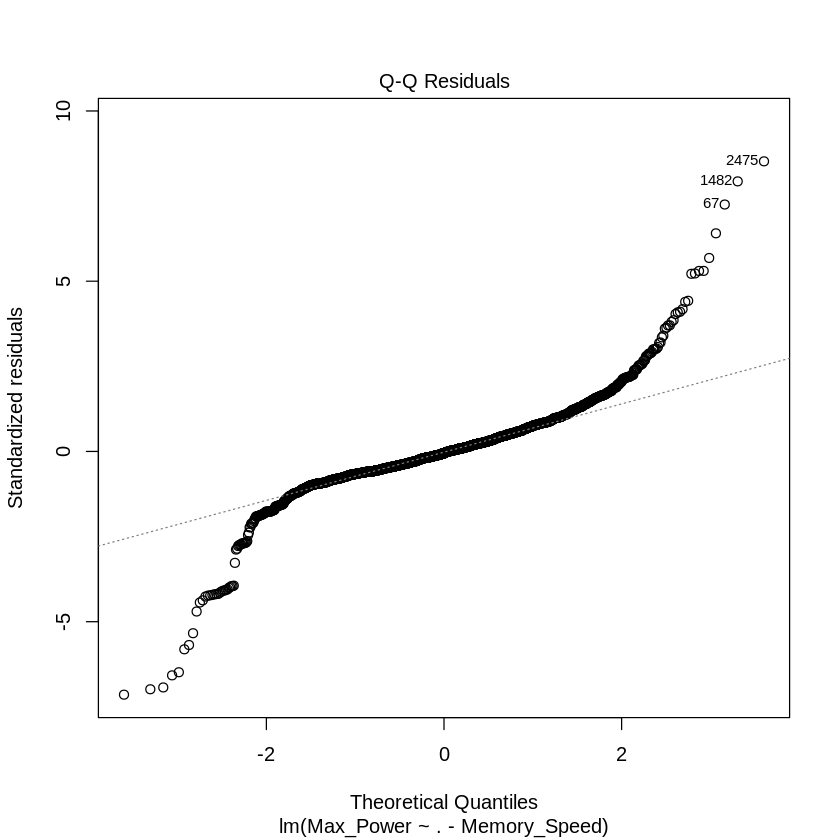

In [334]:
plot(main_model, which = 2)

Ở biểu đồ này, các điểm dữ liệu trong khoảng $Z_{score}$ từ -2 đến 2 đều nằm sát đường nét đứt, tuy nhiên khi đi về 2 phía theo trục x, các điểm dữ liệu càng đi xa đường nét đứt, và đối xứng qua đường nét đứt.
Điều này thể hiện rằng, mật độ giá trị sai số giao động quanh giá trị 0 cao hơn so với theo phân phối chuẩn, khiến cho phân phối của sai số có dạng chuông nhọn, đuôi nặng.

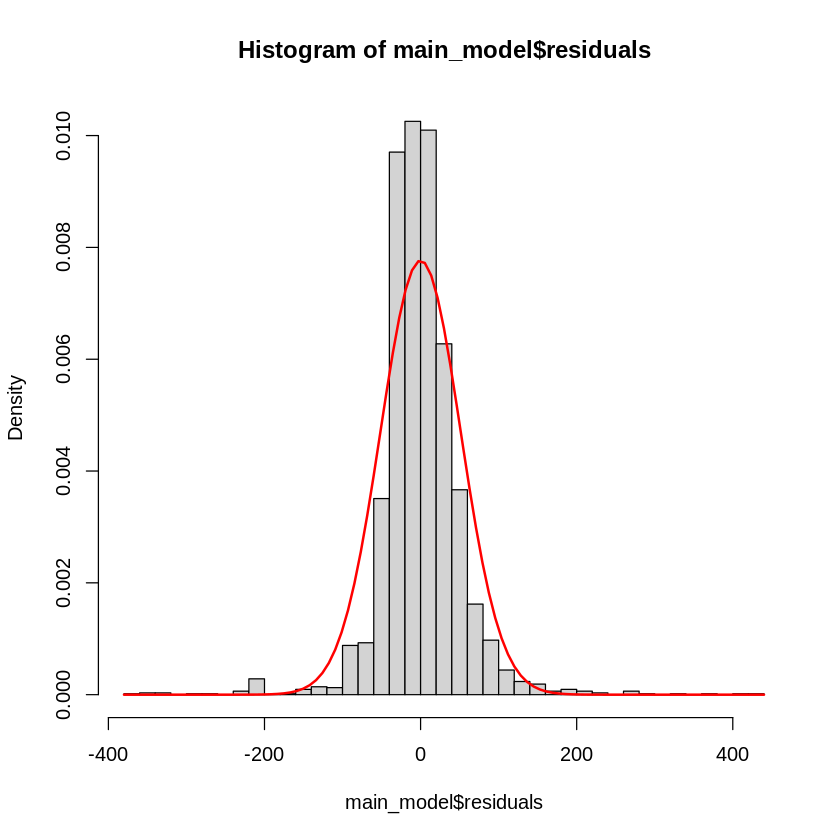

In [338]:
hist(main_model$residuals, breaks = 50, freq = FALSE)
m <- mean(main_model$residuals)
std <- sd(main_model$residuals)
curve(dnorm(x, mean = m, sd = std), col = "red", lwd = 2, add = TRUE)

Đến đây, ta dường như đã có thể kết luận rằng giả định về phân phối chuẩn cũng đã bị vi phạm. Tuy nhiên ta có thể kiểm tra một cách chính quy hơn bằng kiểm định Shapiro-Wilk:
- $H_0$: phân phối của sai số là phân phối chuẩn.
- $H_1$: phân phối của sai số không tuân theo phân phối chuẩn.

In [339]:
set.seed(42)
shapiro.test(main_model$residuals)


	Shapiro-Wilk normality test

data:  main_model$residuals
W = 0.87065, p-value < 2.2e-16


Với mức ý nghĩa 5%, kiểm định trên cũng bác bỏ $H_0$. Phù hợp với nhận định của ta khi đánh giá Q-Q plot.

In [307]:
# system("rm -rv btl_xstk", intern = TRUE)
# rm(list = ls())

## Tài liệu tham khảo: